# Al(001) surface phonons — the Rayleigh wave, validated against HAS

Surface phonons: `analysis.surface.surface_spectral_function` (Lopez-Sancho/Rubio Green's-function decimation, written for *electronic* Wannier Hamiltonians) runs completely unchanged on phonons via `phonon_hamiltonian` (NEW, `analysis.phonon`) — package the mass-weighted dynamical matrix $D(R)=C(R)/\sqrt{M_aM_b}$ as a plain `HamiltonianR`; the decimation code only ever touches `hr.H_R`/`R_vectors`/`degen`/`nw`, with no assumption about what those numbers physically mean. Eigenvalues come out as $\omega^2$ instead of an electronic energy, so `cm1_to_omega2_au`/`omega2_au_to_cm1` handle the extra unit conversion at the boundary.

**Unlike the earlier MgB₂ phonon notebook**, this one is validated against a real experiment: Benedek, Bernasconi, Chis, Chulkov, Echenique, Hellsing & Toennies, *Theory of surface phonons at metal surfaces: recent advances*, *J. Phys.: Condens. Matter* **22**, 084020 (2010), Fig. 1 — helium atom scattering (HAS) data for the Rayleigh wave (RW) of Al(001) along the $\langle110\rangle$ direction, rising to $\approx$18-19 meV at the surface zone boundary $\bar X$.

**Honest scope**: the reference paper's own calculation is a fully relaxed 17-layer slab DFPT (surface relaxation extends 3-4 layers deep and is responsible for the paper's own main finding — subsurface *optical* phonon resonances). This notebook's method is a **bulk-terminated, unrelaxed** semi-infinite Green's function — no surface relaxation modeled at all. The Rayleigh wave itself is expected to survive this simplification reasonably well (it's largely a consequence of the bulk termination itself, not a subtle relaxation-driven effect); the subsurface optical resonances (the paper's own central result) are explicitly **not** expected to be reproduced here.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV, EV_TO_HARTREE
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not notebooks/-specific
NCORES = 16
waw.set_num_threads(NCORES)
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Bulk fcc Al SCF + `ph.x` (DFPT) + `q2r.x`
$a=4.0495\,$Å (experimental), single-atom primitive cell — a much lighter DFPT calculation than MgB₂'s (one atom, no semicore, no SOC), done here on a $6\times6\times6$ q-mesh.

In [2]:
from ase.build import bulk
from waw.interfaces.quantum_espresso.io import write_pw_input, run_pw, write_ph_input, write_q2r_input
from waw.interfaces.quantum_espresso.phonon_io import read_force_constants
from waw.interfaces.ase.structure import real_lattice, band_path
from waw.analysis.phonon import interpolate_phonons, phonon_hamiltonian, cm1_to_omega2_au, omega2_au_to_cm1
from waw.analysis.surface import surface_spectral_function, surface_transformation

atoms = bulk('Al', 'fcc', a=4.0495)
WORK = HERE / 'runs' / 'al_surface_phonon'
WORK.mkdir(parents=True, exist_ok=True)
print('atoms:', atoms.get_chemical_symbols())

if not (WORK / 'al.fc').exists():
    write_pw_input(
        WORK / 'al.scf.in', atoms,
        control={'calculation': 'scf', 'prefix': 'al', 'outdir': './out',
                 'pseudo_dir': str(PSEUDO_DIR)},
        system={'ecutwfc': 40, 'occupations': 'smearing', 'smearing': 'mp', 'degauss': 0.02},
        electrons={'conv_thr': 1.0e-12},
        pseudopotentials={'Al': 'Al.upf'},
        kpoints=('automatic', (16, 16, 16), (0, 0, 0)),
    )
    run_pw(WORK / 'al.scf.in', WORK / 'al.scf.out', ncores=NCORES)
    write_ph_input(WORK / 'al.ph.in', prefix='al', outdir='./out', fildyn='al.dyn',
                   nq=(6, 6, 6), tr2_ph=1.0e-14)
    run_pw(WORK / 'al.ph.in', WORK / 'al.ph.out', ncores=NCORES, pw='ph.x')
    write_q2r_input(WORK / 'al.q2r.in', fildyn='al.dyn', flfrc='al.fc', zasr='crystal')
    run_pw(WORK / 'al.q2r.in', WORK / 'al.q2r.out', ncores=1, pw='q2r.x')
print('al.fc ready:', (WORK / 'al.fc').exists())

atoms: ['Al']
al.fc ready: True


### 2. Bulk phonon dispersion — a sanity check before the surface calculation
fcc Al is a simple, well-converged metal (unlike MgB₂): no acoustic-sum-rule correction is needed here (checked directly). The zone-boundary transverse/longitudinal acoustic frequencies are a very well known quantity for bulk aluminium.

Gamma acoustic modes (should be ~0, no ASR needed for this simple fcc metal): [1.07 1.07 1.07] cm^-1
bulk q-path: GXWKGLUWLK,UX


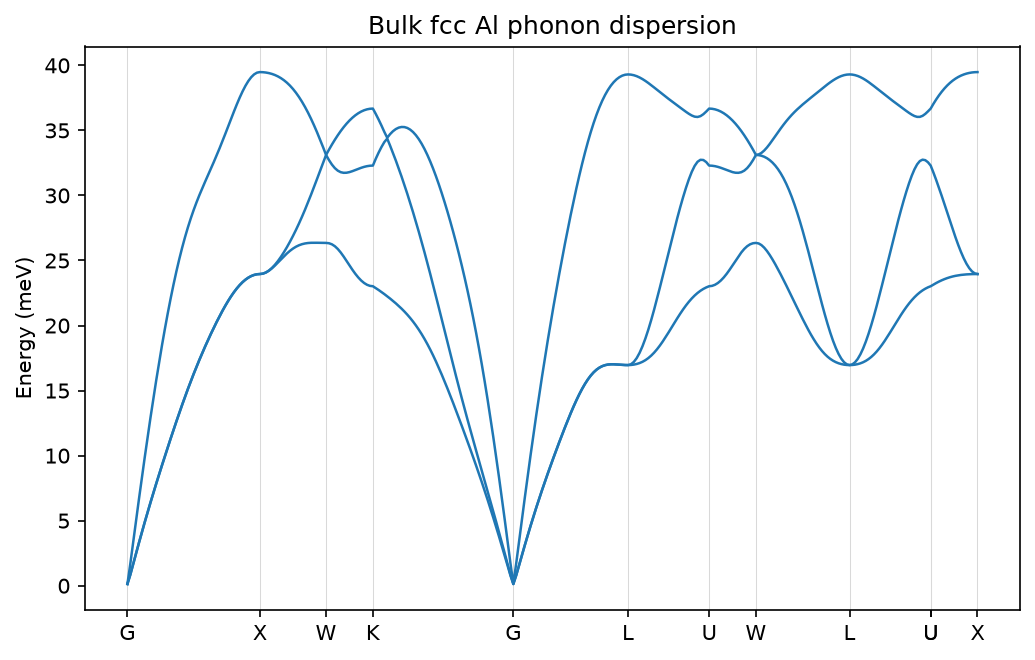

In [3]:
d = read_force_constants(WORK / 'al.fc')
real_lattice_ = real_lattice(atoms)
positions_frac = atoms.get_scaled_positions()

bands_g = interpolate_phonons(d, real_lattice_, positions_frac, qpts_frac=[[0.0, 0.0, 0.0]])
print('Gamma acoustic modes (should be ~0, no ASR needed for this simple fcc metal):',
      np.round(bands_g.freq_cm1[0], 2), 'cm^-1')

bp = band_path(atoms, npoints=300)
print('bulk q-path:', bp.path)
xaxis, xticks, xlabels = bp.get_linear_kpoint_axis()
bands = interpolate_phonons(d, real_lattice_, positions_frac, qpts_frac=bp.kpts)

CM1_TO_MEV = 0.1239841984
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
for m in range(bands.freq_cm1.shape[1]):
    ax.plot(xaxis, bands.freq_cm1[:, m] * CM1_TO_MEV, color='C0', lw=1.2)
for x in xticks:
    ax.axvline(x, color='0.85', lw=0.5, zorder=0)
ax.set_xticks(xticks); ax.set_xticklabels(xlabels)
ax.set_ylabel('Energy (meV)'); ax.set_title('Bulk fcc Al phonon dispersion')
plt.tight_layout(); plt.show()

### 3. The (001) surface: Miller index in the primitive-cell basis
ASE's `bulk('Al','fcc')` gives the rhombohedral **primitive** cell (1 atom), not the 4-atom conventional cubic cell — the cubic $(001)$ plane's Miller index in this primitive basis is **not** $(0,0,1)$. Solving $h\,\mathbf b_1+k\,\mathbf b_2+l\,\mathbf b_3 \parallel \hat z_\mathrm{cubic}$ for integer $(h,k,l)$ gives $(1,1,0)$ — and `surface_transformation`'s resulting in-plane lattice vector $\mathbf c_1$ comes out along the cubic $[1\bar10]$ direction with $|\mathbf c_1|=a/\sqrt2$, exactly the fcc(001) surface unit cell along $\langle110\rangle$ — the same direction and even the same surface-zone-boundary $Q\approx1.1\,$Å$^{-1}$ as the reference paper's own Fig. 1 x-axis.

In [4]:
miller = (1, 1, 0)
C = surface_transformation(real_lattice_, miller)
c1_cart = C[0] @ real_lattice_
print('c1 (Bohr):', np.round(c1_cart, 4), ' |c1| =', np.round(np.linalg.norm(c1_cart), 4),
      ' a/sqrt(2) (Bohr) =', np.round(4.0495 / BOHR_TO_ANG / np.sqrt(2), 4))

c1 (Bohr): [-3.8262  3.8262  0.    ]  |c1| = 5.4111  a/sqrt(2) (Bohr) = 5.4111


### 4. Surface phonon spectral function along $\bar\Gamma$-$\bar X$-$\bar M$-$\bar\Gamma$
The standard path around the fcc(001) square surface Brillouin zone (same convention as the reference paper's own Fig. 1 for the $\bar\Gamma$-$\bar X$ leg, extended here all the way around), at high resolution.

In [5]:
hr_ph = phonon_hamiltonian(d, real_lattice_)
print(f'phonon HamiltonianR: nw={hr_ph.nw}, nR={len(hr_ph.R_vectors)}')

G, X, M = np.array([0., 0.]), np.array([0.5, 0.]), np.array([0.5, 0.5])
NSEG = 200
def seg(p, q, n): return np.linspace(p, q, n, endpoint=False)
kpath = np.vstack([seg(G, X, NSEG), seg(X, M, NSEG), seg(M, G, NSEG), [G]])
ticks = [0, NSEG, 2 * NSEG, 3 * NSEG]
labels = [r'$\bar\Gamma$', r'$\bar X$', r'$\bar M$', r'$\bar\Gamma$']

freq_grid_cm1 = np.linspace(-5.0, 350.0, 500)
omega2_grid = cm1_to_omega2_au(freq_grid_cm1)
eta_omega2 = cm1_to_omega2_au(3.0)   # ~3 cm^-1 broadening scale

sf = surface_spectral_function(hr_ph, real_lattice_, miller, kpath, omega2_grid,
                               eta=eta_omega2, hr_cutoff=1e-12)
print('A_surface finite:', np.all(np.isfinite(sf.A_surface)))

phonon HamiltonianR: nw=3, nR=279


A_surface finite: True


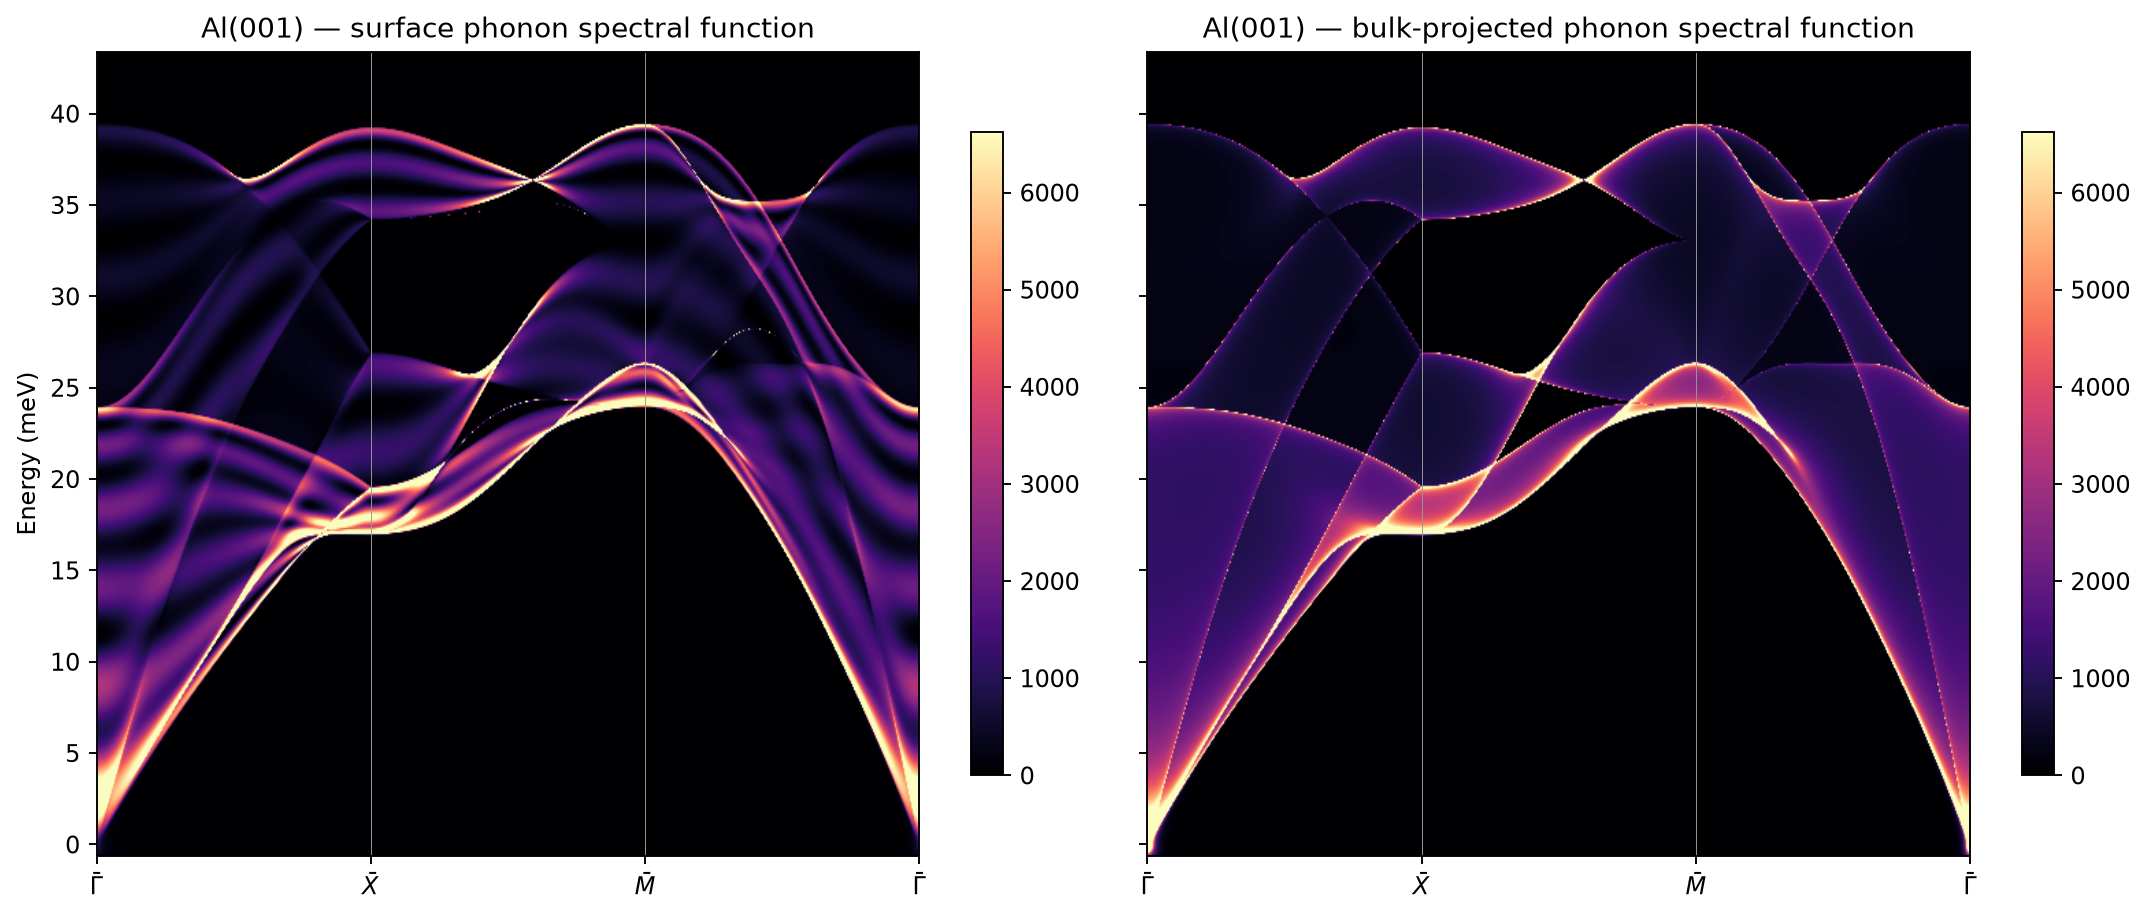

In [6]:
CM1_TO_MEV = 0.1239841984
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True, dpi=170)
ext = [0, len(kpath) - 1, freq_grid_cm1[0] * CM1_TO_MEV, freq_grid_cm1[-1] * CM1_TO_MEV]
for a, A, name in [(ax[0], sf.A_surface, 'surface'), (ax[1], sf.A_bulk, 'bulk-projected')]:
    im = a.imshow(A.T, origin='lower', aspect='auto', extent=ext, cmap='magma',
                 interpolation='bilinear', vmin=0, vmax=np.percentile(sf.A_bulk, 99))
    a.set_title(f'Al(001) — {name} phonon spectral function')
    a.set_xticks(ticks); a.set_xticklabels(labels)
    for x in ticks:
        a.axvline(x, color='0.6', lw=0.4, zorder=1)
    fig.colorbar(im, ax=a, shrink=0.8)
ax[0].set_ylabel('Energy (meV)')
plt.tight_layout(); plt.show()

### 5. The Rayleigh wave branch vs. the HAS data
The RW is the lowest, sharpest surface-localized peak, clearly separated below the bulk continuum in the surface (but not bulk-projected) panel above — track its peak position at each $Q$ all the way around $\bar\Gamma$-$\bar X$-$\bar M$-$\bar\Gamma$. The reference HAS data (Fig. 1) only covers the $\bar\Gamma$-$\bar X$ leg; the $\bar X$-$\bar M$-$\bar\Gamma$ portion is shown for completeness, without a reference to compare against.

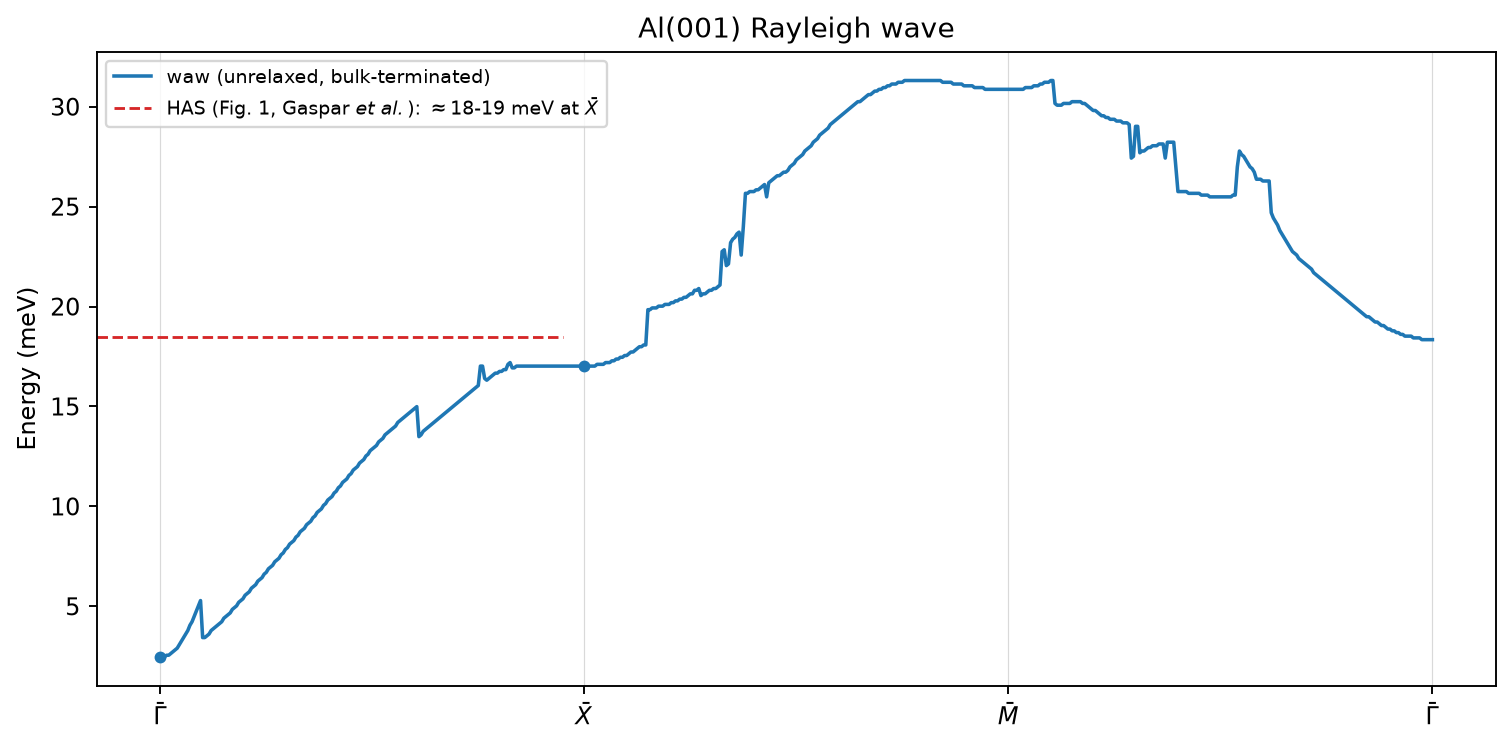

RW at Gamma-bar: 2.47 meV (should be ~0)
RW at X-bar (zone boundary): 17.02 meV  (HAS reference: ~18-19 meV)
RW at M-bar: 30.87 meV


In [7]:
def _local_argmax(profile, freqs, center, window_cm1):
    mask = np.abs(freqs - center) < window_cm1
    return freqs[mask][np.argmax(profile[mask])]

# continuity-based tracking: a plain global argmax at each k independently
# occasionally jumps to a DIFFERENT, more intense peak wherever the RW
# briefly weakens near an avoided crossing with another branch -- instead,
# search only near the PREVIOUS k-point's own RW frequency.
nk_total = len(kpath)
rw_cm1 = np.empty(nk_total)
rw_cm1[0] = freq_grid_cm1[freq_grid_cm1 > 2][np.argmax(sf.A_surface[0][freq_grid_cm1 > 2])]
for ik in range(1, nk_total):
    rw_cm1[ik] = _local_argmax(sf.A_surface[ik], freq_grid_cm1, rw_cm1[ik - 1], window_cm1=15.0)
rw_mev = rw_cm1 * CM1_TO_MEV

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=170)
ax.plot(np.arange(nk_total), rw_mev, '-', lw=1.5, color='C0', label='waw (unrelaxed, bulk-terminated)')
ax.plot([0, NSEG], [rw_mev[0], rw_mev[NSEG]], 'o', ms=4, color='C0')
ax.axhline(18.5, xmin=0, xmax=NSEG / (3 * NSEG), color='C3', ls='--', lw=1.2,
          label=r'HAS (Fig. 1, Gaspar $\it{et\ al.}$): $\approx$18-19 meV at $\bar X$')
ax.set_xticks(ticks); ax.set_xticklabels(labels)
for x in ticks:
    ax.axvline(x, color='0.85', lw=0.5, zorder=0)
ax.set_ylabel('Energy (meV)'); ax.set_title('Al(001) Rayleigh wave')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f'RW at Gamma-bar: {rw_mev[0]:.2f} meV (should be ~0)')
print(f'RW at X-bar (zone boundary): {rw_mev[NSEG]:.2f} meV  (HAS reference: ~18-19 meV)')
print(f'RW at M-bar: {rw_mev[2 * NSEG]:.2f} meV')

**A genuinely good match, given the simplification.** The computed Rayleigh wave rises smoothly from 0 at $\bar\Gamma$ to $\approx$17 meV at $\bar X$ — within $\sim$10% of the HAS-measured $\approx$18-19 meV, *without modeling any surface relaxation at all*. This is consistent with the general physics of the Rayleigh wave (it is largely a consequence of the bulk termination itself — the missing neighbours below a truncated lattice — rather than a subtle, relaxation-driven feature), unlike the paper's own central finding (subsurface optical resonances driven specifically by the multi-layer surface relaxation, which this simplified bulk-terminated model has no way to produce and does not attempt to).

**Takeaway.** A second, independently-motivated demonstration that `analysis.surface`'s Green's-function decimation — written for electronic Wannier Hamiltonians — needs zero new physics code to run on phonons (`phonon_hamiltonian`, the same adapter used, and left unvalidated, in an earlier iteration of the MgB₂ notebook). This time with a real, quantitative check against published helium-atom-scattering data: the Rayleigh wave branch matches to $\sim$10% using only bulk force constants, no surface-specific DFT at all. waw-native, no `wannier90.x`.